In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [2]:
l_exp = [f"Regression/BET_ResNet3"]

data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    #exp = "DefaultExp"
    print(f"🔔 Starting {exp}")
    stream = open(f"exp_list/{exp}.yaml", 'r')
    param  = yaml.safe_load(stream)
    param["TRAINING"]["DEVICE"] = 'mps'

    resultsPath = os.path.join("results", exp)

    # Create the directory
    if not os.path.exists(resultsPath):
        os.makedirs(resultsPath)

    myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

    # Train the network
    train_losses, val_losses =  myNetwork.train()

    # Test the network
    #myNetwork.loadWeight()
    #myNetwork.test()   





🔄 Chargement des données: 100%|██████████| 50/50 [00:01<00:00, 29.31exp/s]


🔔 Starting Regression/BET_ResNet3


KeyError: 'NB_FRAMES'

In [4]:
print(len(myNetwork.dataSetTrain))
print(len(myNetwork.dataSetTest))
print(len(myNetwork.dataSetVal))

39640
4955
4955


In [ ]:
num_params = sum(p.numel() for p in myNetwork.model.parameters())
print(f"Number of parameters: {num_params}") 
# V1 = 2.147.874.498
# V2 = 8.482.754
# V3 = 2.190.530
# V_reg = 2.190.465
# V_reg_48CH = 12.833.441
# V_reg4 = 8.505.697
# V_reg5 = 3.201.769
# Res Net = 11.175.554

Number of parameters: 11175554


[0.32091756 0.1865818  0.15773604 0.13845296 0.12024673 0.10727626
 0.09677573 0.08687289 0.07693826 0.06956954 0.06164188 0.05427512
 0.049957   0.04420088 0.04088343 0.03705721 0.03435643 0.03189997
 0.03029756 0.02836598 0.02714965 0.02455273 0.02387125 0.02368347
 0.02255569 0.0211756  0.02157481 0.01973386 0.01916642 0.01910802
 0.01825571 0.01723747 0.01760833 0.01724395 0.01678553 0.01672242
 0.01638344 0.01566923 0.01508521 0.0150265 ]
[0.17069781 0.14446684 0.13275167 0.13359542 0.12419782 0.11062112
 0.11078395 0.12368512 0.12686794 0.11657571 0.11951459 0.11763913
 0.19994734 0.14733829 0.11350906 0.12481887 0.12256472 0.11292198
 0.12235139 0.18709712 0.11642761 0.12108704 0.12672955 0.37218184
 0.12311759 0.12458109 0.11320435 0.1080534  0.19357441 0.11657773
 0.10450764 0.28237835 0.10519364 0.16142101 0.11715657 0.11012588
 0.13488228 0.1129483  0.11111994 0.14780439]


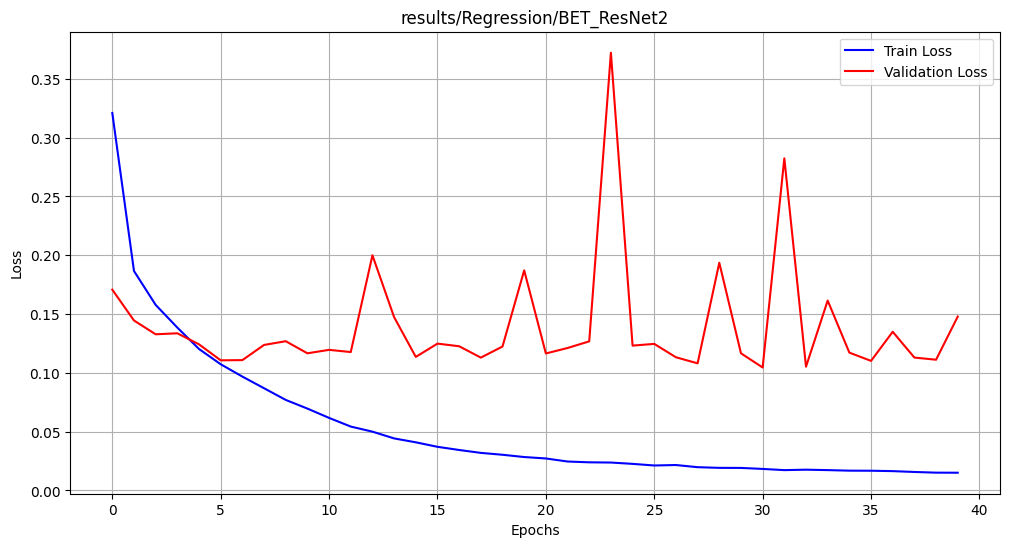

In [4]:
# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)